In [1]:
# @title Установка зависимостей
!pip install torch ultralytics opencv-python tqdm numpy deep_sort_realtime --quiet
!pip install scikit-learn matplotlib seaborn --quiet

print("✅ Все зависимости установлены")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 72.1 MB/s eta 0:00:00
✅ Все зависимости установлены


In [2]:
# @title Импорт библиотек и настройка
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from ultralytics import YOLO
from collections import deque
from tqdm import tqdm
import itertools
import math
from deep_sort_realtime.deepsort_tracker import DeepSort
import warnings
warnings.filterwarnings('ignore')

# Настройка устройства
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Используется устройство: {DEVICE}")

# Фиксируем сиды для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✅ Окружение настроено")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 Используется устройство: cuda
✅ Окружение настроено


#ЛСТМ модель

## 🎯 Конфигурация параметров

Централизованная конфигурация всех параметров системы для удобной настройки.

In [3]:
# @title Конфигурация системы
class Config:
    # Параметры моделей
    NUM_KEYPOINTS = 20
    SEQ_LENGTH = 120  # Длина последовательности для LSTM
    WINDOW_SIZE = 120

    # Пороговые значения
    DETECTION_CONFIDENCE = 0.3
    POSE_CONFIDENCE = 0.5
    DEFECATION_THRESHOLD = 0.7

    # Параметры трекинга
    TRACKER_MAX_AGE = 45
    TRACKER_N_INIT = 3
    TRACKER_MAX_IOU = 0.7

    # Параметры сглаживания
    POSE_SMOOTH_WINDOW = 5
    PROB_SMOOTH_WINDOW = 5

    # Временные параметры (в секундах)
    DEFECATION_MIN_DURATION = 2.0
    CLEANING_TIMEOUT = 15.0
    CLEANING_MIN_DURATION = 5.0
    MIN_DEFECATION_INTERVAL = 20.0

    # Пространственные параметры
    CLEANING_RADIUS = 50  # пикселей
    MIN_BBOX_SIZE = 30    # минимальный размер bbox собаки

    # Пути к моделям
    DOG_DETECT_MODEL_PATH = "/content/drive/MyDrive/Система контроля за собаками/dog_detect_model_yolo8_450ep.pt"
    DOG_POSE_MODEL_PATH = "/content/drive/MyDrive/Система контроля за собаками/data/dog_pose_model_yolo8_14.pt"
    LSTM_MODEL_PATH = "/content/drive/MyDrive/Система контроля за собаками/data/structured_lstm_model_final.pth"

    # Режимы работы
    VISUALIZE_ALL_DETECTIONS = True
    SAVE_INTERMEDIATE_FRAMES = False
    VERBOSE_LOGGING = True

config = Config()
print("✅ Конфигурация загружена")

✅ Конфигурация загружена


## Улучшенный процессор позы

Этот класс отвечает за фильтрацию шума в ключевых точках, их интерполяцию и временное сглаживание.

**Ключевые улучшения:**
- Фильтрация по confidence score
- Медианное сглаживание по времени
- Интерполяция пропущенных точек
- Приоритизация важных точек для детекции дефекации

In [4]:
# @title Улучшенный процессор позы
class ImprovedPoseProcessor:
    """
    Улучшенный процессор позы с фильтрацией шума и сглаживанием
    """

    def __init__(self, num_keypoints=20, confidence_threshold=0.5, smooth_window=5):
        self.num_keypoints = num_keypoints
        self.confidence_threshold = confidence_threshold
        self.smooth_window = smooth_window
        self.keypoints_history = deque(maxlen=smooth_window)

        # Важные группы ключевых точек для собаки
        self.keypoint_groups = {
            'spine': [0, 1, 2, 3, 4, 5],      # Позвоночник
            'hips': [6, 7, 8, 9],              # Таз/бедра
            'tail': [10, 11, 12],              # Хвост и анус (11 - ключевая)
            'front_legs': [13, 14, 15],        # Передние лапы
            'rear_legs': [16, 17, 18, 19]      # Задние лапы
        }

        # Приоритет точек для определения дефекации
        self.defecation_priority = [11, 8, 7, 6, 9]

    def filter_keypoints(self, keypoints, confidences=None):
        """
        Фильтрация и сглаживание ключевых точек
        """
        if keypoints is None or len(keypoints) == 0:
            return None

        # Создаем копию для обработки
        filtered_kps = keypoints.copy()

        # 1. Фильтрация по уверенности
        if confidences is not None:
            filtered_kps[confidences < self.confidence_threshold] = 0

        # 2. Интерполяция пропущенных точек в позвоночнике
        filtered_kps = self._interpolate_spine(filtered_kps)

        # 3. Временное сглаживание
        self.keypoints_history.append(filtered_kps)
        if len(self.keypoints_history) >= 3:
            # Используем медиану для устойчивости к выбросам
            smoothed = np.median(list(self.keypoints_history)[-3:], axis=0)
            return smoothed

        return filtered_kps

    def _interpolate_spine(self, keypoints):
        """
        Линейная интерполяция пропущенных точек позвоночника
        """
        spine_indices = self.keypoint_groups['spine']

        # Находим валидные точки позвоночника
        valid_points = []
        for i in spine_indices:
            if i < len(keypoints) and keypoints[i].sum() > 0:
                valid_points.append(i)

        if len(valid_points) >= 2:
            # Интерполируем пропущенные точки
            for i in spine_indices:
                if i not in valid_points:
                    # Находим ближайшие валидные точки
                    prev_idx = max([v for v in valid_points if v < i], default=None)
                    next_idx = min([v for v in valid_points if v > i], default=None)

                    if prev_idx is not None and next_idx is not None:
                        # Линейная интерполяция
                        alpha = (i - prev_idx) / (next_idx - prev_idx)
                        keypoints[i] = (1 - alpha) * keypoints[prev_idx] + alpha * keypoints[next_idx]
                    elif prev_idx is not None:
                        keypoints[i] = keypoints[prev_idx]
                    elif next_idx is not None:
                        keypoints[i] = keypoints[next_idx]

        return keypoints

    def get_stable_defecation_point(self, keypoints):
        """
        Получение стабильной точки дефекации с проверкой на устойчивость
        """
        # Проверяем точки в порядке приоритета
        for point_idx in self.defecation_priority:
            if point_idx >= len(keypoints):
                continue

            if keypoints[point_idx].sum() > 0:
                # Проверяем стабильность точки в истории
                if len(self.keypoints_history) >= 3:
                    history_list = list(self.keypoints_history)
                    points_history = [h[point_idx] for h in history_list[-3:]
                                    if h[point_idx].sum() > 0]

                    if len(points_history) >= 2:
                        # Вычисляем дисперсию
                        variance = np.var(points_history, axis=0).sum()
                        if variance < 100:  # Порог стабильности
                            return tuple(map(int, keypoints[point_idx]))
                else:
                    return tuple(map(int, keypoints[point_idx]))

        return None

    def get_keypoint_confidence(self, keypoints):
        """
        Оценка общей уверенности в позе
        """
        if keypoints is None:
            return 0.0

        # Считаем долю валидных точек
        valid_count = np.sum(keypoints.sum(axis=1) > 0)
        total_count = min(len(keypoints), self.num_keypoints)

        # Бонус за наличие ключевых точек
        has_tail = 1.0 if len(keypoints) > 11 and keypoints[11].sum() > 0 else 0.0
        has_hips = 1.0 if len(keypoints) > 8 and keypoints[8].sum() > 0 else 0.0

        base_confidence = valid_count / total_count if total_count > 0 else 0
        return base_confidence * (1.0 + 0.3 * has_tail + 0.2 * has_hips) / 1.5

print("✅ Класс ImprovedPoseProcessor определен")

✅ Класс ImprovedPoseProcessor определен


##  Улучшенный трекер собак

Робастный трекер с механизмами реидентификации и выбора наилучшего трека.

**Ключевые улучшения:**
- Реидентификация потерянных треков по визуальным признакам
- Многокритериальный выбор основного трека
- Сохранение истории треков для анализа стабильности
- Автоматическое восстановление после потерь

In [5]:
# @title Улучшенный трекер собак
class RobustDogTracker:
    """
    Улучшенный трекер с реидентификацией и выбором лучшего трека
    """

    def __init__(self, max_age=45, n_init=3, max_iou_distance=0.7):
        # Инициализация DeepSORT
        self.tracker = DeepSort(
            max_age=max_age,
            n_init=n_init,
            max_iou_distance=max_iou_distance
        )

        # Хранилища для реидентификации
        self.appearance_features = {}  # track_id -> список признаков
        self.track_history = {}        # track_id -> история позиций
        self.primary_track_id = None
        self.lost_tracks = {}          # track_id -> время потери

        # Параметры
        self.track_switch_threshold = 10  # кадров для переключения
        self.switch_counter = 0
        self.max_history_length = 50

    def update(self, frame, detections):
        """
        Обновление треков и выбор основного
        """
        # 1. Стандартное обновление DeepSORT
        tracks = self.tracker.update_tracks(detections, frame=frame)

        # 2. Обновление признаков для активных треков
        for track in tracks:
            if track.is_confirmed():
                self._update_track_features(frame, track)

        # 3. Выбор основного трека
        primary_track = self._select_primary_track(tracks)

        # 4. Управление переключением треков
        if primary_track:
            self._handle_track_switch(primary_track)

        # 5. Обновление статуса потерянных треков
        self._update_lost_tracks()

        return tracks, self._get_primary_track(tracks)

    def _update_track_features(self, frame, track):
        """
        Обновление признаков внешности для трека
        """
        track_id = track.track_id
        x1, y1, x2, y2 = map(int, track.to_ltrb())

        # Проверяем валидность bbox
        if x2 <= x1 or y2 <= y1:
            return

        roi = frame[y1:y2, x1:x2]
        if roi.size == 0:
            return

        # Вычисляем признаки внешности
        features = self._compute_appearance_features(roi)

        # Сохраняем признаки
        if track_id not in self.appearance_features:
            self.appearance_features[track_id] = deque(maxlen=self.max_history_length)
        self.appearance_features[track_id].append(features)

        # Сохраняем позицию
        if track_id not in self.track_history:
            self.track_history[track_id] = deque(maxlen=self.max_history_length)
        self.track_history[track_id].append({
            'bbox': track.to_ltrb(),
            'center': ((x1 + x2) // 2, (y1 + y2) // 2),
            'area': (x2 - x1) * (y2 - y1)
        })

    def _compute_appearance_features(self, roi):
        """
        Вычисление устойчивых признаков внешности
        """
        # Ресайз для стандартизации
        roi_resized = cv2.resize(roi, (64, 64))

        # HSV гистограмма (устойчива к освещению)
        hsv = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1], None, [16, 16], [0, 180, 0, 256])
        cv2.normalize(hist, hist)

        # Градиенты HOG (упрощенная версия)
        gray = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2GRAY)
        grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0)
        grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1)
        grad_mag = np.sqrt(grad_x**2 + grad_y**2)

        # Разбиваем на блоки и считаем среднюю магнитуду
        hog_features = []
        for i in range(0, 64, 16):
            for j in range(0, 64, 16):
                block = grad_mag[i:i+16, j:j+16]
                hog_features.append(np.mean(block))

        # Объединяем признаки
        features = np.concatenate([hist.flatten(), np.array(hog_features)])

        return features / (np.linalg.norm(features) + 1e-6)

    def _select_primary_track(self, tracks):
        """
        Многокритериальный выбор основного трека
        """
        confirmed_tracks = [t for t in tracks if t.is_confirmed()]

        if not confirmed_tracks:
            return None

        if len(confirmed_tracks) == 1:
            return confirmed_tracks[0]

        # Оцениваем каждый трек
        scores = {}
        for track in confirmed_tracks:
            track_id = track.track_id
            score = 0

            # 1. Размер трека
            x1, y1, x2, y2 = track.to_ltrb()
            area = (x2 - x1) * (y2 - y1)
            score += min(area / 10000, 1.0) * 25

            # 2. Возраст трека
            age = len(self.track_history.get(track_id, []))
            score += min(age / 30, 1.0) * 25

            # 3. Стабильность движения
            if track_id in self.track_history and len(self.track_history[track_id]) >= 5:
                centers = [h['center'] for h in list(self.track_history[track_id])[-5:]]
                variance = np.var(centers, axis=0).sum()
                stability = 1.0 / (1.0 + variance / 1000)
                score += stability * 25

            # 4. Бонус за текущий основной трек
            if track_id == self.primary_track_id:
                score += 25

            scores[track_id] = score

        # Возвращаем трек с максимальным score
        best_id = max(scores, key=scores.get)
        return next(t for t in confirmed_tracks if t.track_id == best_id)

    def _handle_track_switch(self, new_primary_track):
        """
        Управление переключением основного трека
        """
        new_id = new_primary_track.track_id

        if self.primary_track_id is None:
            self.primary_track_id = new_id
            self.switch_counter = 0
        elif new_id != self.primary_track_id:
            self.switch_counter += 1
            if self.switch_counter >= self.track_switch_threshold:
                print(f"🔄 Переключение основного трека: {self.primary_track_id} -> {new_id}")
                self.primary_track_id = new_id
                self.switch_counter = 0
        else:
            self.switch_counter = 0

    def _update_lost_tracks(self):
        """
        Обновление статуса потерянных треков
        """
        # Увеличиваем счетчик потери для неактивных треков
        for track_id in list(self.lost_tracks.keys()):
            self.lost_tracks[track_id] += 1

            # Удаляем слишком старые потерянные треки
            if self.lost_tracks[track_id] > self.tracker.max_age * 2:
                del self.lost_tracks[track_id]

    def _get_primary_track(self, tracks):
        """
        Получение текущего основного трека
        """
        if self.primary_track_id is None:
            return None

        for track in tracks:
            if track.track_id == self.primary_track_id and track.is_confirmed():
                return track

        return None

    def get_track_confidence(self, track):
        """
        Оценка уверенности в треке
        """
        if track is None:
            return 0.0

        track_id = track.track_id
        confidence = 0.0

        # Возраст трека
        age = len(self.track_history.get(track_id, []))
        confidence += min(age / 30, 1.0) * 0.4

        # Стабильность
        if track_id in self.track_history and len(self.track_history[track_id]) >= 5:
            centers = [h['center'] for h in list(self.track_history[track_id])[-5:]]
            variance = np.var(centers, axis=0).sum()
            stability = 1.0 / (1.0 + variance / 1000)
            confidence += stability * 0.3

        # Размер
        x1, y1, x2, y2 = track.to_ltrb()
        area = (x2 - x1) * (y2 - y1)
        confidence += min(area / 10000, 1.0) * 0.3

        return min(confidence, 1.0)

print("✅ Класс RobustDogTracker определен")

✅ Класс RobustDogTracker определен


## Компактный экстрактор признаков

Значительно уменьшенная размерность признаков (с 11400 до ~100) с сохранением информативности.

**Ключевые улучшения:**
- Только важные связи скелета (вместо всех комбинаций)
- Нормализация координат относительно центра
- Специфичные признаки для позы дефекации
- Учет скоростей движения ключевых точек

In [6]:
# @title Компактный экстрактор признаков
class EfficientFeatureExtractor:
    """
    Экстрактор признаков с уменьшенной размерностью
    """

    def __init__(self, num_keypoints=20):
        self.num_keypoints = num_keypoints

        # Предопределенные важные связи скелета собаки
        self.key_connections = [
            # Позвоночник
            (0, 1), (1, 2), (2, 3), (3, 4), (4, 5),
            # Таз
            (5, 6), (6, 7), (7, 8), (8, 9),
            # Хвост
            (9, 10), (10, 11), (11, 12),
            # Передние лапы
            (2, 13), (13, 14), (14, 15),
            # Задние лапы
            (6, 16), (16, 17), (17, 18),
            (8, 19),
            # Дополнительные связи
            (5, 9), (2, 6), (13, 16)  # Диагональные связи
        ]

        # Важные углы для детекции дефекации
        self.key_angles = [
            (5, 6, 7),    # Угол спины к тазу
            (9, 10, 11),  # Угол основания хвоста
            (2, 5, 8),    # Изгиб позвоночника
            (6, 8, 16),   # Положение задних лап
            (1, 2, 5),    # Наклон шеи
        ]

    def extract_features(self, keypoints, prev_keypoints=None):
        """
        Извлечение компактных признаков
        """
        features = []

        # 1. Нормализованные координаты относительно центра
        center = self._get_center(keypoints)
        if center is not None:
            for kp in keypoints[:15]:  # Берем первые 15 точек
                if kp.sum() > 0:
                    norm_kp = (kp - center) / 100.0
                    features.extend(norm_kp)
                else:
                    features.extend([0.0, 0.0])
        else:
            features.extend([0.0] * 30)

        # 2. Нормализованные длины сегментов
        for (i, j) in self.key_connections:
            if i < len(keypoints) and j < len(keypoints):
                if keypoints[i].sum() > 0 and keypoints[j].sum() > 0:
                    length = np.linalg.norm(keypoints[i] - keypoints[j]) / 100.0
                    features.append(min(length, 2.0))
                else:
                    features.append(0.0)

        # 3. Ключевые углы
        for (i, j, k) in self.key_angles:
            angle = self._compute_angle(keypoints, i, j, k)
            features.append(angle / np.pi)

        # 4. Скорости ключевых точек
        if prev_keypoints is not None:
            for i in range(min(len(keypoints), 10)):
                if keypoints[i].sum() > 0 and prev_keypoints[i].sum() > 0:
                    velocity = np.linalg.norm(keypoints[i] - prev_keypoints[i]) / 50.0
                    features.append(min(velocity, 2.0))
                else:
                    features.append(0.0)
        else:
            features.extend([0.0] * 10)

        # 5. Специфичные признаки дефекации
        defecation_features = self._extract_defecation_features(keypoints)
        features.extend(defecation_features)

        # 6. Признаки позы
        pose_features = self._extract_pose_features(keypoints)
        features.extend(pose_features)

        return np.array(features, dtype=np.float32)

    def _get_center(self, keypoints):
        """
        Вычисление центра масс валидных точек
        """
        valid_points = keypoints[keypoints.sum(axis=1) > 0]
        if len(valid_points) > 0:
            return np.median(valid_points, axis=0)
        return None

    def _compute_angle(self, keypoints, i, j, k):
        """
        Вычисление угла между тремя точками
        """
        if i >= len(keypoints) or j >= len(keypoints) or k >= len(keypoints):
            return 0.0

        if keypoints[i].sum() == 0 or keypoints[j].sum() == 0 or keypoints[k].sum() == 0:
            return 0.0

        vec1 = keypoints[i] - keypoints[j]
        vec2 = keypoints[k] - keypoints[j]

        norm1 = np.linalg.norm(vec1)
        norm2 = np.linalg.norm(vec2)

        if norm1 < 1e-6 or norm2 < 1e-6:
            return 0.0

        cosine = np.dot(vec1, vec2) / (norm1 * norm2)
        cosine = np.clip(cosine, -1.0, 1.0)

        return np.arccos(cosine)

    def _extract_defecation_features(self, keypoints):
        """
        Специфичные признаки позы дефекации
        """
        features = []

        # Высота таза относительно плеч
        if len(keypoints) > 6:
            shoulders = keypoints[2] if keypoints[2].sum() > 0 else None
            hips = keypoints[6] if keypoints[6].sum() > 0 else None

            if shoulders is not None and hips is not None:
                height_diff = (hips[1] - shoulders[1]) / 100.0
                features.append(height_diff)
            else:
                features.append(0.0)

        # Угол наклона спины
        if len(keypoints) > 5:
            neck = keypoints[1] if keypoints[1].sum() > 0 else None
            tail_base = keypoints[5] if keypoints[5].sum() > 0 else None

            if neck is not None and tail_base is not None:
                spine_angle = np.arctan2(tail_base[1] - neck[1],
                                        tail_base[0] - neck[0])
                features.append(spine_angle / np.pi)
            else:
                features.append(0.0)

        # Изгиб хвоста
        if len(keypoints) > 12:
            tail_points = [keypoints[i] for i in [9, 10, 11, 12]
                          if i < len(keypoints) and keypoints[i].sum() > 0]
            if len(tail_points) >= 2:
                tail_curve = self._compute_curvature(tail_points)
                features.append(min(tail_curve, 1.0))
            else:
                features.append(0.0)

        return features

    def _extract_pose_features(self, keypoints):
        """
        Общие признаки позы
        """
        features = []

        # Компактность позы (отношение периметра bounding box к площади)
        valid_points = keypoints[keypoints.sum(axis=1) > 0]
        if len(valid_points) >= 3:
            min_xy = valid_points.min(axis=0)
            max_xy = valid_points.max(axis=0)
            width = max_xy[0] - min_xy[0]
            height = max_xy[1] - min_xy[1]

            if width > 0 and height > 0:
                aspect_ratio = height / width
                features.append(min(aspect_ratio, 3.0) / 3.0)
            else:
                features.append(0.0)
        else:
            features.append(0.0)

        # Симметричность позы
        if len(keypoints) > 15:
            left_leg = keypoints[13:16] if all(keypoints[13:16].sum(axis=1) > 0) else None
            right_leg = keypoints[16:19] if all(keypoints[16:19].sum(axis=1) > 0) else None

            if left_leg is not None and right_leg is not None:
                left_center = np.mean(left_leg, axis=0)
                right_center = np.mean(right_leg, axis=0)
                symmetry = 1.0 - min(np.linalg.norm(left_center - right_center) / 100.0, 1.0)
                features.append(symmetry)
            else:
                features.append(0.0)

        return features

    def _compute_curvature(self, points):
        """
        Вычисление кривизны линии по точкам
        """
        if len(points) < 3:
            return 0.0

        # Вычисляем углы между последовательными сегментами
        angles = []
        for i in range(len(points) - 2):
            vec1 = points[i+1] - points[i]
            vec2 = points[i+2] - points[i+1]

            norm1 = np.linalg.norm(vec1)
            norm2 = np.linalg.norm(vec2)

            if norm1 > 1e-6 and norm2 > 1e-6:
                cosine = np.dot(vec1, vec2) / (norm1 * norm2)
                angle = np.arccos(np.clip(cosine, -1.0, 1.0))
                angles.append(angle)

        if angles:
            return np.mean(angles) / np.pi
        return 0.0

    def get_feature_dim(self):
        """
        Возвращает размерность вектора признаков
        """
        # Создаем тестовый вектор для вычисления размерности
        test_kps = np.ones((self.num_keypoints, 2))
        features = self.extract_features(test_kps)
        return len(features)

print("✅ Класс EfficientFeatureExtractor определен")

✅ Класс EfficientFeatureExtractor определен


##Уменьшенная версия LSTM классификатора с энкодером для сжатия признаков.

**Ключевые улучшения:**
- Энкодер для уменьшения размерности входа
- Меньше параметров (~500K вместо ~2M)
- Attention механизм для фокуса на важных кадрах
- Оптимизированная архитектура

In [7]:
# @title Компактная LSTM модель
class CompactLSTMPoseClassifier(nn.Module):
    """
    Компактная LSTM модель с энкодером признаков
    """

    def __init__(self, input_size, lstm_hidden=128, num_layers=2, dropout=0.3):
        super().__init__()

        # Энкодер для сжатия признаков
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 32)
        )

        # Двунаправленная LSTM
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        # Attention механизм
        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1, bias=False)
        )

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1)
        )

        # Инициализация весов
        self._initialize_weights()

    def _initialize_weights(self):
        """
        Инициализация весов модели
        """
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight' in name:
                        nn.init.orthogonal_(param)
                    elif 'bias' in name:
                        nn.init.constant_(param, 0)
                        # Устанавливаем forget gate bias в 1
                        n = param.size(0)
                        param[n//4:n//2].data.fill_(1)

    def forward(self, x):
        """
        Прямой проход
        x: (batch_size, seq_len, feature_dim)
        """
        batch_size, seq_len, feat_dim = x.shape

        # Сжатие признаков
        x = x.view(-1, feat_dim)
        x = self.encoder(x)
        x = x.view(batch_size, seq_len, -1)

        # LSTM
        outputs, (h_n, c_n) = self.lstm(x)

        # Attention
        att_weights = torch.softmax(self.attention(outputs), dim=1)
        context = torch.sum(att_weights * outputs, dim=1)

        # Классификация
        return self.classifier(context)

    def get_attention_weights(self, x):
        """
        Получение весов внимания для интерпретации
        """
        batch_size, seq_len, feat_dim = x.shape

        x = x.view(-1, feat_dim)
        x = self.encoder(x)
        x = x.view(batch_size, seq_len, -1)

        outputs, _ = self.lstm(x)
        att_weights = torch.softmax(self.attention(outputs), dim=1)

        return att_weights.squeeze(-1)

print("✅ Класс CompactLSTMPoseClassifier определен")

✅ Класс CompactLSTMPoseClassifier определен


##  Основной класс детектора

Объединение всех компонентов в единую систему детекции дефекации.

In [8]:
# @title Основной класс детектора
class ImprovedDefecationDetector:
    """
    Улучшенный детектор дефекации с оптимизированной архитектурой
    """

    def __init__(self, dog_detect_model, pose_model, lstm_path=None,
                 config=Config()):

        self.config = config
        self.device = DEVICE

        # Модели
        self.dog_detect_model = dog_detect_model
        self.pose_model = pose_model
        self.human_detect_model = YOLO("yolov8n.pt")
        self.human_pose_model = YOLO("yolov8n-pose.pt")

        # Компоненты
        self.pose_processor = ImprovedPoseProcessor(
            num_keypoints=config.NUM_KEYPOINTS,
            confidence_threshold=config.POSE_CONFIDENCE,
            smooth_window=config.POSE_SMOOTH_WINDOW
        )

        self.tracker = RobustDogTracker(
            max_age=config.TRACKER_MAX_AGE,
            n_init=config.TRACKER_N_INIT,
            max_iou_distance=config.TRACKER_MAX_IOU
        )

        self.feature_extractor = EfficientFeatureExtractor(
            num_keypoints=config.NUM_KEYPOINTS
        )

        # Инициализация LSTM
        self.feature_dim = self.feature_extractor.get_feature_dim()
        self.lstm_model = self._init_lstm(lstm_path)

        # Буферы
        self.feature_window = deque(maxlen=config.WINDOW_SIZE)
        self.prob_history = []
        self.prev_keypoints = None
        self.prev_features = None

        # Состояние детекции
        self.defecation_point = None
        self.defecation_point_fixed = None
        self.alert_active = False
        self.defecation_confirmed = False
        self.cleaning_detected = False

        # Тайминги (будут установлены после получения fps)
        self.fps = 30
        self._init_timings()

        # Счетчики кадров
        self.alert_start_frame = None
        self.defecation_frame = None
        self.cleaning_start_frame = None
        self.frame_count = 0

        # Цвета для визуализации
        self.colors = {
            'dog_bbox': (0, 255, 0),
            'person_bbox': (255, 0, 0),
            'keypoint': (0, 255, 255),
            'defecation_zone': (0, 0, 255),
            'alert': (0, 0, 255),
            'normal': (0, 255, 0)
        }

    def _init_lstm(self, lstm_path):
        """
        Инициализация LSTM модели
        """
        model = CompactLSTMPoseClassifier(
            input_size=self.feature_dim * 2,  # base + delta
            lstm_hidden=128,
            num_layers=2,
            dropout=0.3
        ).to(self.device)

        if lstm_path and os.path.exists(lstm_path):
            try:
                state_dict = torch.load(lstm_path, map_location='cpu')
                # Пробуем загрузить с частичным совпадением
                model.load_state_dict(state_dict, strict=False)
                print(f"✅ Загружена предобученная LSTM модель: {lstm_path}")
            except Exception as e:
                print(f"⚠️ Не удалось загрузить LSTM модель: {e}")
                print("   Будет использована неподготовленная модель")
        else:
            print("ℹ️ LSTM модель не загружена (файл не найден)")

        model.eval()
        return model

    def _init_timings(self):
        """
        Инициализация временных параметров в кадрах
        """
        self.defecation_min_frames = int(self.config.DEFECATION_MIN_DURATION * self.fps)
        self.cleaning_timeout_frames = int(self.config.CLEANING_TIMEOUT * self.fps)
        self.cleaning_min_frames = int(self.config.CLEANING_MIN_DURATION * self.fps)
        self.min_interval_frames = int(self.config.MIN_DEFECATION_INTERVAL * self.fps)

    def process_frame(self, frame):
        """
        Обработка одного кадра
        """
        vis_frame = frame.copy()
        h, w = frame.shape[:2]

        # 1. Детекция людей и собак
        human_detections = self._detect_persons(frame)
        dog_detections = self._detect_dogs(frame)

        # 2. Визуализация детекций
        if self.config.VISUALIZE_ALL_DETECTIONS:
            vis_frame = self._visualize_detections(vis_frame, human_detections, dog_detections)

        # 3. Трекинг собак
        tracks, primary_track = self.tracker.update(frame, dog_detections)

        # 4. Обработка основного трека
        if primary_track:
            vis_frame, dog_kps = self._process_dog_track(vis_frame, frame, primary_track)

            # 5. Обновление признаков для LSTM
            if dog_kps is not None:
                self._update_feature_window(dog_kps)

            # 6. Определение точки дефекации
            if dog_kps is not None and not self.defecation_point_fixed:
                self.defecation_point = self.pose_processor.get_stable_defecation_point(dog_kps)
        else:
            # Нет трека - добавляем нулевые признаки
            self._add_zero_features()
            self.prev_keypoints = None
            self.prev_features = None

        # 7. Предсказание LSTM
        if len(self.feature_window) == self.feature_window.maxlen:
            prob = self._predict_defecation()
            self._update_state(prob)
            vis_frame = self._visualize_status(vis_frame, prob)

        # 8. Обработка уборки
        if self.defecation_point_fixed:
            vis_frame = self._check_cleaning(vis_frame, frame, human_detections)

        # 9. Визуализация зоны дефекации
        if self.defecation_point_fixed:
            vis_frame = self._visualize_defecation_zone(vis_frame)

        self.frame_count += 1
        return vis_frame

    def _detect_persons(self, frame):
        """
        Детекция людей в кадре
        """
        results = self.human_detect_model(frame, verbose=False)[0]
        detections = []

        if results.boxes is not None:
            for box, cls, conf in zip(results.boxes.xyxy.cpu().numpy(),
                                      results.boxes.cls.cpu().numpy(),
                                      results.boxes.conf.cpu().numpy()):
                if int(cls) == 0 and conf > 0.5:  # class 0 = person
                    x1, y1, x2, y2 = map(int, box)
                    w, h = x2 - x1, y2 - y1
                    if w >= 50 and h >= 100:  # Минимальный размер человека
                        detections.append({
                            'bbox': (x1, y1, x2, y2),
                            'conf': float(conf),
                            'size': (w, h)
                        })

        return detections

    def _detect_dogs(self, frame):
        """
        Детекция собак в кадре
        """
        results = self.dog_detect_model(frame, verbose=False)[0]
        detections = []

        if results.boxes is not None:
            for box, cls, conf in zip(results.boxes.xyxy.cpu().numpy(),
                                      results.boxes.cls.cpu().numpy(),
                                      results.boxes.conf.cpu().numpy()):
                if results.names[int(cls)] == "dog" and conf > self.config.DETECTION_CONFIDENCE:
                    x1, y1, x2, y2 = map(int, box)
                    w, h = x2 - x1, y2 - y1
                    if w >= self.config.MIN_BBOX_SIZE and h >= self.config.MIN_BBOX_SIZE:
                        detections.append(([x1, y1, w, h], float(conf), "dog"))

        return detections

    def _process_dog_track(self, vis_frame, frame, track):
        """
        Обработка трека собаки: извлечение позы и признаков
        """
        x1, y1, x2, y2 = map(int, track.to_ltrb())

        # Визуализация bbox основного трека
        cv2.rectangle(vis_frame, (x1, y1), (x2, y2), self.colors['dog_bbox'], 2)
        track_conf = self.tracker.get_track_confidence(track)
        cv2.putText(vis_frame, f"Dog ID:{track.track_id} ({track_conf:.2f})",
                   (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.colors['dog_bbox'], 2)

        # Проверка размера
        if x2 - x1 < 10 or y2 - y1 < 10:
            return vis_frame, None

        # Кроп ROI
        roi = frame[y1:y2, x1:x2]
        if roi.size == 0:
            return vis_frame, None

        # Детекция позы
        pose_results = self.pose_model(roi, verbose=False)[0]

        if pose_results.keypoints is None or len(pose_results.keypoints) == 0:
            return vis_frame, None

        # Извлечение ключевых точек
        kps = pose_results.keypoints[0].xy[0].cpu().numpy()
        confs = None
        if hasattr(pose_results.keypoints[0], 'conf'):
            confs = pose_results.keypoints[0].conf[0].cpu().numpy()

        # Перевод в глобальные координаты
        kps[:, 0] += x1
        kps[:, 1] += y1

        # Дополнение до нужного количества точек
        full_kps = np.zeros((self.config.NUM_KEYPOINTS, 2))
        valid_count = min(len(kps), self.config.NUM_KEYPOINTS)
        full_kps[:valid_count] = kps[:valid_count]

        # Фильтрация позы
        filtered_kps = self.pose_processor.filter_keypoints(full_kps, confs)

        if filtered_kps is not None:
            # Визуализация ключевых точек
            for idx, (px, py) in enumerate(filtered_kps):
                if px > 0 and py > 0:
                    cv2.circle(vis_frame, (int(px), int(py)), 3,
                              self.colors['keypoint'], -1)

            return vis_frame, filtered_kps

        return vis_frame, None

    def _update_feature_window(self, keypoints):
        """
        Обновление окна признаков для LSTM
        """
        # Извлечение признаков
        features = self.feature_extractor.extract_features(
            keypoints, self.prev_keypoints
        )

        # Вычисление delta
        if self.prev_features is not None:
            delta = features - self.prev_features
        else:
            delta = np.zeros_like(features)

        # Сохранение
        self.prev_keypoints = keypoints.copy()
        self.prev_features = features.copy()

        # Добавление в окно
        combined = np.concatenate([features, delta])
        self.feature_window.append(combined)

    def _add_zero_features(self):
        """
        Добавление нулевых признаков при отсутствии детекции
        """
        zero_features = np.zeros(self.feature_dim)
        combined = np.concatenate([zero_features, zero_features])
        self.feature_window.append(combined)

    def _predict_defecation(self):
        """
        Предсказание вероятности дефекации
        """
        seq = np.array(list(self.feature_window))
        seq_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(self.device)

        with torch.no_grad():
            logits = self.lstm_model(seq_tensor)
            prob = torch.sigmoid(logits).item()

        return prob

    def _update_state(self, prob):
        """
        Обновление состояния детектора на основе вероятности
        """
        self.prob_history.append(prob)
        if len(self.prob_history) > self.config.PROB_SMOOTH_WINDOW:
            self.prob_history.pop(0)

        avg_prob = np.mean(self.prob_history) if self.prob_history else prob

        # Логика подтверждения дефекации
        if avg_prob > self.config.DEFECATION_THRESHOLD:
            if not self.alert_active:
                self.alert_active = True
                self.alert_start_frame = self.frame_count
                if self.config.VERBOSE_LOGGING:
                    print(f"🚨 Alert started at frame {self.frame_count} (prob: {avg_prob:.3f})")

            # Проверка длительности
            alert_duration = self.frame_count - self.alert_start_frame
            if (alert_duration >= self.defecation_min_frames and
                self.defecation_point is not None and
                not self.defecation_confirmed):

                self.defecation_confirmed = True
                self.defecation_point_fixed = self.defecation_point
                self.defecation_frame = self.frame_count

                if self.config.VERBOSE_LOGGING:
                    print(f"💩 Defecation CONFIRMED at frame {self.frame_count}")
                    print(f"   Point: {self.defecation_point_fixed}")
        else:
            if self.alert_active:
                self.alert_active = False
                self.alert_start_frame = None
                if self.config.VERBOSE_LOGGING:
                    print(f"✅ Alert ended at frame {self.frame_count} (prob: {avg_prob:.3f})")

    def _check_cleaning(self, vis_frame, frame, human_detections):
        """
        Проверка уборки за собакой
        """
        # Проверка таймаута
        time_since_defecation = self.frame_count - self.defecation_frame

        if time_since_defecation > self.cleaning_timeout_frames:
            if not self.cleaning_detected:
                # Нарушение - не убрали вовремя
                cv2.putText(vis_frame, "⚠️ VIOLATION: NOT CLEANED!",
                           (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

        # Проверка приближения рук к зоне
        for det in human_detections:
            x1, y1, x2, y2 = det['bbox']

            if x2 - x1 >= 10 and y2 - y1 >= 10:
                roi = frame[y1:y2, x1:x2]
                if roi.size > 0:
                    pose_results = self.human_pose_model(roi, verbose=False)[0]

                    if pose_results.keypoints is not None and len(pose_results.keypoints) > 0:
                        kps = pose_results.keypoints[0].xy[0].cpu().numpy()
                        kps[:, 0] += x1
                        kps[:, 1] += y1

                        # Проверка расстояния от запястий до зоны
                        if self._is_hand_near_zone(kps):
                            if self.cleaning_start_frame is None:
                                self.cleaning_start_frame = self.frame_count
                            else:
                                cleaning_duration = self.frame_count - self.cleaning_start_frame
                                if cleaning_duration >= self.cleaning_min_frames:
                                    self.cleaning_detected = True
                                    cv2.putText(vis_frame, f"🧹 CLEANING: {cleaning_duration/self.fps:.1f}s",
                                               (x1, y1-30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                        else:
                            self.cleaning_start_frame = None

        # Сброс при подтвержденной уборке
        if self.cleaning_detected:
            self._reset_defecation_state()
            cv2.putText(vis_frame, "✅ CLEANED", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

        return vis_frame

    def _is_hand_near_zone(self, human_kps):
        """
        Проверка близости рук к зоне дефекации
        """
        if self.defecation_point_fixed is None:
            return False

        # Индексы запястий: 9 (левое), 10 (правое)
        wrist_indices = [9, 10]

        for idx in wrist_indices:
            if idx < len(human_kps) and human_kps[idx].sum() > 0:
                wrist = human_kps[idx]
                distance = np.sqrt((wrist[0] - self.defecation_point_fixed[0])**2 +
                                  (wrist[1] - self.defecation_point_fixed[1])**2)

                if distance < self.config.CLEANING_RADIUS:
                    return True

        return False

    def _reset_defecation_state(self):
        """
        Сброс состояния после уборки
        """
        self.defecation_point = None
        self.defecation_point_fixed = None
        self.alert_active = False
        self.defecation_confirmed = False
        self.cleaning_detected = False
        self.alert_start_frame = None
        self.defecation_frame = None
        self.cleaning_start_frame = None

    def _visualize_detections(self, vis_frame, human_detections, dog_detections):
        """
        Визуализация всех детекций
        """
        # Люди
        for det in human_detections:
            x1, y1, x2, y2 = det['bbox']
            cv2.rectangle(vis_frame, (x1, y1), (x2, y2), self.colors['person_bbox'], 2)
            cv2.putText(vis_frame, f"Person {det['conf']:.2f}", (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.colors['person_bbox'], 2)

        # Собаки (все детекции до трекинга)
        for det in dog_detections:
            bbox, conf, _ = det
            x1, y1, w, h = bbox
            cv2.rectangle(vis_frame, (x1, y1), (x1+w, y1+h), (0, 165, 255), 1)

        return vis_frame

    def _visualize_status(self, vis_frame, prob):
        """
        Визуализация статуса детекции
        """
        avg_prob = np.mean(self.prob_history) if self.prob_history else prob

        # Статус
        if self.defecation_confirmed:
            status = "DEFECATION CONFIRMED"
            color = self.colors['alert']
        elif self.alert_active:
            status = f"ALERT ({avg_prob:.2f})"
            color = (0, 165, 255)
        else:
            status = f"NORMAL ({avg_prob:.2f})"
            color = self.colors['normal']

        cv2.putText(vis_frame, status, (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

        # Дополнительная информация
        if self.defecation_confirmed and self.defecation_frame:
            time_elapsed = (self.frame_count - self.defecation_frame) / self.fps
            time_left = max(0, self.config.CLEANING_TIMEOUT - time_elapsed)
            cv2.putText(vis_frame, f"Time to clean: {time_left:.1f}s", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        return vis_frame

    def _visualize_defecation_zone(self, vis_frame):
        """
        Визуализация зоны дефекации
        """
        if self.defecation_point_fixed:
            x, y = self.defecation_point_fixed
            zone_size = self.config.CLEANING_RADIUS

            # Рисуем круг
            cv2.circle(vis_frame, (x, y), zone_size, self.colors['defecation_zone'], 2)

            # Крестик в центре
            cv2.line(vis_frame, (x-10, y), (x+10, y), self.colors['defecation_zone'], 2)
            cv2.line(vis_frame, (x, y-10), (x, y+10), self.colors['defecation_zone'], 2)

            # Подпись
            cv2.putText(vis_frame, "DEFECATION ZONE", (x+15, y-15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, self.colors['defecation_zone'], 2)

        return vis_frame

    def run_video(self, video_path, output_path=None):
        """
        Обработка видеофайла
        """
        print(f"🎬 Обработка видео: {video_path}")

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Не удалось открыть видео: {video_path}")

        # Получение параметров видео
        self.fps = cap.get(cv2.CAP_PROP_FPS)
        if self.fps <= 0:
            self.fps = 30

        self._init_timings()

        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        print(f"📊 FPS: {self.fps:.1f}, Размер: {width}x{height}, Кадров: {total_frames}")

        # Инициализация видеописателя
        writer = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            writer = cv2.VideoWriter(output_path, fourcc, self.fps, (width, height))

        # Сброс состояния
        self.frame_count = 0
        self._reset_defecation_state()
        self.feature_window.clear()
        self.prob_history.clear()

        # Обработка
        pbar = tqdm(total=total_frames, desc="Обработка кадров", unit="кадр")

        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                vis_frame = self.process_frame(frame)

                if writer:
                    writer.write(vis_frame)

                pbar.update(1)

        except Exception as e:
            print(f"❌ Ошибка при обработке: {e}")
        finally:
            cap.release()
            if writer:
                writer.release()
            pbar.close()

        print(f"✅ Обработка завершена. Результат сохранен в: {output_path}" if output_path else "✅ Обработка завершена")

print("✅ Класс ImprovedDefecationDetector определен")

✅ Класс ImprovedDefecationDetector определен


## 📦 Загрузка моделей

Загрузка предобученных моделей YOLO для детекции собак и позы.

In [9]:
# @title Загрузка моделей
# Подключаем Google Drive (если нужно)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive подключен")
except:
    print("ℹ️ Работа в локальном режиме")

# Загрузка моделей
print("\n📥 Загрузка моделей...")

# Модель детекции собак
try:
    dog_detect_model = YOLO(config.DOG_DETECT_MODEL_PATH)
    print(f"✅ Модель детекции собак загружена: {config.DOG_DETECT_MODEL_PATH}")
except Exception as e:
    print(f"⚠️ Не удалось загрузить модель детекции собак: {e}")
    print("   Будет использована стандартная модель YOLO")
    dog_detect_model = YOLO("yolov8n.pt")

# Модель позы собак
try:
    pose_model = YOLO(config.DOG_POSE_MODEL_PATH)
    print(f"✅ Модель позы собак загружена: {config.DOG_POSE_MODEL_PATH}")
except Exception as e:
    print(f"⚠️ Не удалось загрузить модель позы: {e}")
    print("   Будет использована стандартная pose-модель")
    pose_model = YOLO("yolov8n-pose.pt")

print("\n✅ Все модели загружены")

Mounted at /content/drive
✅ Google Drive подключен

📥 Загрузка моделей...
✅ Модель детекции собак загружена: /content/drive/MyDrive/Система контроля за собаками/dog_detect_model_yolo8_450ep.pt
✅ Модель позы собак загружена: /content/drive/MyDrive/Система контроля за собаками/data/dog_pose_model_yolo8_14.pt

✅ Все модели загружены


## Инициализация детектора

Создание экземпляра улучшенного детектора.

In [10]:
# @title Инициализация детектора
detector = ImprovedDefecationDetector(
    dog_detect_model=dog_detect_model,
    pose_model=pose_model,
    lstm_path=config.LSTM_MODEL_PATH,
    config=config
)

print("✅ Детектор инициализирован")
print(f"📐 Размерность признаков: {detector.feature_dim}")
print(f"🖥️ Устройство: {detector.device}")

⚠️ Не удалось загрузить LSTM модель: Error(s) in loading state_dict for CompactLSTMPoseClassifier:
	size mismatch for lstm.weight_ih_l0: copying a param with shape torch.Size([1024, 10260]) from checkpoint, the shape in current model is torch.Size([512, 32]).
	size mismatch for lstm.weight_hh_l0: copying a param with shape torch.Size([1024, 256]) from checkpoint, the shape in current model is torch.Size([512, 128]).
	size mismatch for lstm.bias_ih_l0: copying a param with shape torch.Size([1024]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for lstm.bias_hh_l0: copying a param with shape torch.Size([1024]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for lstm.weight_ih_l0_reverse: copying a param with shape torch.Size([1024, 10260]) from checkpoint, the shape in current model is torch.Size([512, 32]).
	size mismatch for lstm.weight_hh_l0_reverse: copying a param with shape torch.Size([1024, 256]) from checkpoint, t

## Скачивание результата

Скачивание обработанного видео (для Google Colab).

In [11]:
# @title Скачивание результата
try:
    from google.colab import files
    if os.path.exists(OUTPUT_VIDEO):
        print(f"📥 Скачивание файла: {OUTPUT_VIDEO}")
        files.download(OUTPUT_VIDEO)
    else:
        print(f"❌ Файл не найден: {OUTPUT_VIDEO}")
except ImportError:
    print("ℹ️ Функция скачивания доступна только в Google Colab")
    print(f"📁 Результат сохранен в: {OUTPUT_VIDEO}")

NameError: name 'OUTPUT_VIDEO' is not defined

## Тестирование на одном кадре (для отладки)

Функция для тестирования детектора на отдельном изображении.

In [ ]:
# @title Тестирование на изображении
def test_on_image(image_path):
    """
    Тестирование детектора на отдельном изображении
    """
    if not os.path.exists(image_path):
        print(f"❌ Файл не найден: {image_path}")
        return

    # Сброс состояния
    detector._reset_defecation_state()
    detector.feature_window.clear()
    detector.prob_history.clear()
    detector.frame_count = 0

    # Загрузка изображения
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Не удалось загрузить изображение: {image_path}")
        return

    # Обработка
    vis_image = detector.process_frame(image)

    # Отображение
    from google.colab.patches import cv2_imshow
    cv2_imshow(vis_image)

    print(f"✅ Обработка завершена")

# Пример использования
# test_on_image("/path/to/test/image.jpg")
print("ℹ️ Функция test_on_image() готова к использованию")

ℹ️ Функция test_on_image() готова к использованию


## 📊 Анализ производительности

Оценка производительности детектора (FPS, использование памяти).

In [11]:
# @title Анализ производительности
import time

def benchmark_detector(video_path, num_frames=100):
    """
    Бенчмарк производительности детектора
    """
    if not os.path.exists(video_path):
        print(f"❌ Файл не найден: {video_path}")
        return

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Не удалось открыть видео: {video_path}")
        return

    # Сброс состояния
    detector._reset_defecation_state()
    detector.feature_window.clear()
    detector.prob_history.clear()
    detector.frame_count = 0

    # Измерение производительности
    processing_times = []

    print(f"📊 Запуск бенчмарка на {num_frames} кадрах...")

    for i in tqdm(range(num_frames), desc="Измерение"):
        ret, frame = cap.read()
        if not ret:
            break

        start_time = time.time()
        _ = detector.process_frame(frame)
        processing_times.append(time.time() - start_time)

    cap.release()

    # Статистика
    if processing_times:
        avg_time = np.mean(processing_times)
        fps = 1.0 / avg_time if avg_time > 0 else 0

        print(f"\n📈 Результаты бенчмарка:")
        print(f"   Среднее время на кадр: {avg_time*1000:.1f} мс")
        print(f"   FPS: {fps:.1f}")
        print(f"   Мин/Макс время: {min(processing_times)*1000:.1f} / {max(processing_times)*1000:.1f} мс")

        # Оценка компонентов
        print(f"\n🔧 Параметры модели:")
        print(f"   Устройство: {detector.device}")
        print(f"   Размерность признаков: {detector.feature_dim}")
        print(f"   Длина окна LSTM: {detector.config.WINDOW_SIZE}")

        # Подсчет параметров LSTM
        total_params = sum(p.numel() for p in detector.lstm_model.parameters())
        trainable_params = sum(p.numel() for p in detector.lstm_model.parameters() if p.requires_grad)
        print(f"\n🧠 LSTM модель:")
        print(f"   Всего параметров: {total_params:,}")
        print(f"   Обучаемых параметров: {trainable_params:,}")

# Запуск бенчмарка (если есть тестовое видео)
# benchmark_detector("/path/to/test/video.mp4", num_frames=100)
print("ℹ️ Функция benchmark_detector() готова к использованию")

ℹ️ Функция benchmark_detector() готова к использованию


## 📝 Экспорт модели

Функция для экспорта обученной LSTM модели.

In [12]:
# @title Экспорт модели
def export_model(output_path="improved_lstm_model.pth"):
    """
    Экспорт LSTM модели в файл
    """
    # Сохранение state_dict
    torch.save(detector.lstm_model.state_dict(), output_path)
    print(f"✅ Модель сохранена: {output_path}")

    # Сохранение конфигурации
    import json
    config_dict = {
        'feature_dim': detector.feature_dim,
        'window_size': detector.config.WINDOW_SIZE,
        'threshold': detector.config.DEFECATION_THRESHOLD,
        'input_size': detector.feature_dim * 2
    }

    config_path = output_path.replace('.pth', '_config.json')
    with open(config_path, 'w') as f:
        json.dump(config_dict, f, indent=2)
    print(f"✅ Конфигурация сохранена: {config_path}")

    # Скачивание (для Colab)
    try:
        from google.colab import files
        files.download(output_path)
        files.download(config_path)
    except:
        pass

# export_model("my_improved_model.pth")
print("ℹ️ Функция export_model() готова к использованию")

ℹ️ Функция export_model() готова к использованию


## Подготовка данных для обучения LSTM

Создание датасета из размеченных видео с актами дефекации и без.

In [12]:
# @title Подготовка данных для обучения
import os
import json
from sklearn.model_selection import train_test_split

class DefecationDataset(Dataset):
    """
    Датасет для обучения LSTM модели
    """
    def __init__(self, sequences, labels, augment=False):
        self.sequences = sequences
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx].astype(np.float32)
        label = self.labels[idx]

        # Аугментация при обучении
        if self.augment:
            seq = self._augment_sequence(seq)

        return torch.tensor(seq), torch.tensor(label, dtype=torch.float32)

    def _augment_sequence(self, seq):
        """
        Аугментация последовательности
        """
        # 1. Добавление небольшого шума
        if np.random.random() > 0.5:
            noise = np.random.normal(0, 0.01, seq.shape)
            seq = seq + noise

        # 2. Временное масштабирование (растяжение/сжатие)
        if np.random.random() > 0.7:
            scale = np.random.uniform(0.9, 1.1)
            new_len = int(len(seq) * scale)
            indices = np.linspace(0, len(seq)-1, new_len)
            seq = np.array([np.interp(indices, np.arange(len(seq)), seq[:, i])
                           for i in range(seq.shape[1])]).T

            # Обрезка или дополнение до исходной длины
            if len(seq) > len(self.sequences[0]):
                seq = seq[:len(self.sequences[0])]
            else:
                pad = np.zeros((len(self.sequences[0]) - len(seq), seq.shape[1]))
                seq = np.vstack([seq, pad])

        return seq.astype(np.float32)


class DataPreparator:
    """
    Подготовка данных из видеофайлов
    """
    def __init__(self, detector, config):
        self.detector = detector
        self.config = config
        self.feature_extractor = detector.feature_extractor
        self.pose_processor = detector.pose_processor

    def extract_sequences_from_video(self, video_path, label, stride=30):
        """
        Извлечение последовательностей признаков из видео

        Args:
            video_path: путь к видео
            label: метка класса (0 - нет дефекации, 1 - есть)
            stride: шаг скользящего окна в кадрах
        """
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"❌ Не удалось открыть видео: {video_path}")
            return []

        sequences = []
        feature_buffer = deque(maxlen=self.config.WINDOW_SIZE)
        prev_keypoints = None
        prev_features = None

        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Детекция собак
            dog_results = self.detector.dog_detect_model(frame, verbose=False)[0]
            detections = self._prepare_detections(dog_results)

            if detections:
                # Берем самую уверенную детекцию
                best_det = max(detections, key=lambda x: x[1])
                bbox, conf, _ = best_det
                x1, y1, w, h = bbox
                x2, y2 = x1 + w, y1 + h

                # Извлечение позы
                roi = frame[y1:y2, x1:x2]
                if roi.size > 0:
                    pose_results = self.detector.pose_model(roi, verbose=False)[0]

                    if pose_results.keypoints is not None and len(pose_results.keypoints) > 0:
                        kps = pose_results.keypoints[0].xy[0].cpu().numpy()
                        kps[:, 0] += x1
                        kps[:, 1] += y1

                        # Дополнение до нужного количества точек
                        full_kps = np.zeros((self.config.NUM_KEYPOINTS, 2))
                        valid_count = min(len(kps), self.config.NUM_KEYPOINTS)
                        full_kps[:valid_count] = kps[:valid_count]

                        # Фильтрация позы
                        filtered_kps = self.pose_processor.filter_keypoints(full_kps)

                        if filtered_kps is not None:
                            # Извлечение признаков
                            features = self.feature_extractor.extract_features(
                                filtered_kps, prev_keypoints
                            )

                            # Delta признаки
                            if prev_features is not None:
                                delta = features - prev_features
                            else:
                                delta = np.zeros_like(features)

                            prev_keypoints = filtered_kps.copy()
                            prev_features = features.copy()

                            combined = np.concatenate([features, delta])
                            feature_buffer.append(combined)

                            # Когда буфер заполнен, сохраняем последовательность
                            if len(feature_buffer) == self.config.WINDOW_SIZE:
                                if frame_count % stride == 0:
                                    sequences.append(np.array(list(feature_buffer)))
            else:
                # Нет детекции - добавляем нули
                zero_features = np.zeros(self.detector.feature_dim)
                combined = np.concatenate([zero_features, zero_features])
                feature_buffer.append(combined)

                prev_keypoints = None
                prev_features = None

            frame_count += 1

        cap.release()

        print(f"📊 Извлечено {len(sequences)} последовательностей из {video_path}")
        return sequences

    def _prepare_detections(self, results):
        """
        Подготовка детекций в формате для трекера
        """
        detections = []

        if results.boxes is not None:
            for box, cls, conf in zip(results.boxes.xyxy.cpu().numpy(),
                                      results.boxes.cls.cpu().numpy(),
                                      results.boxes.conf.cpu().numpy()):

                if results.names[int(cls)] == "dog" and conf > self.config.DETECTION_CONFIDENCE:
                    x1, y1, x2, y2 = map(int, box)
                    w, h = x2 - x1, y2 - y1

                    if w >= self.config.MIN_BBOX_SIZE and h >= self.config.MIN_BBOX_SIZE:
                        detections.append(([x1, y1, w, h], float(conf), "dog"))

        return detections

    def prepare_dataset(self, data_dir, classes=['normal', 'defecation']):
        """
        Подготовка полного датасета из директории с видео

        Структура директории:
        data_dir/
            normal/
                video1.mp4
                video2.mp4
                ...
            defecation/
                video1.mp4
                video2.mp4
                ...
        """
        all_sequences = []
        all_labels = []

        for class_idx, class_name in enumerate(classes):
            class_path = os.path.join(data_dir, class_name)

            if not os.path.exists(class_path):
                print(f"⚠️ Директория не найдена: {class_path}")
                continue

            videos = [f for f in os.listdir(class_path)
                     if f.endswith(('.mp4', '.avi', '.mov', '.mkv'))]

            print(f"\n📁 Обработка класса '{class_name}' ({len(videos)} видео)")

            for video in tqdm(videos, desc=f"Класс {class_name}"):
                video_path = os.path.join(class_path, video)
                sequences = self.extract_sequences_from_video(video_path, class_idx)

                all_sequences.extend(sequences)
                all_labels.extend([class_idx] * len(sequences))

        print(f"\n✅ Всего последовательностей: {len(all_sequences)}")
        print(f"   Класс 0 (normal): {all_labels.count(0)}")
        print(f"   Класс 1 (defecation): {all_labels.count(1)}")

        return np.array(all_sequences), np.array(all_labels)

print("✅ Классы для подготовки данных определены")

✅ Классы для подготовки данных определены


## 🏋️ Обучение LSTM модели

Полный цикл обучения с валидацией, планировщиками и early stopping.

In [17]:
# @title Обучение LSTM модели
class LSTMTrainer:
    """
    Тренер для LSTM модели
    """
    def __init__(self, model, device, config):
        self.model = model
        self.device = device
        self.config = config

        # Метрики
        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

    def train(self, train_loader, val_loader, epochs=100,
              learning_rate=1e-4, weight_decay=1e-4,
              patience=15, save_path='best_model.pth'):
        """
        Обучение модели
        """
        # Оптимизатор
        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

        # Планировщик learning rate
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=7
        )

        # Cosine annealing для тонкой настройки
        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=10,
            T_mult=2,
            eta_min=1e-7
        )

        # Функция потерь
        criterion = nn.BCEWithLogitsLoss()

        # Early stopping
        best_val_loss = float('inf')
        patience_counter = 0
        best_epoch = 0

        print("🚀 Начало обучения")
        print("=" * 60)

        for epoch in range(epochs):
            # Обучение
            train_loss, train_acc = self._train_epoch(
                train_loader, optimizer, criterion
            )

            # Валидация
            val_loss, val_acc = self._validate_epoch(val_loader, criterion)

            # Обновление планировщиков
            scheduler.step(val_loss)
            cosine_scheduler.step()

            # Сохранение метрик
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)

            # Вывод прогресса
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:03d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f} | "
                  f"LR: {current_lr:.2e}")

            # Сохранение лучшей модели
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch = epoch + 1
                patience_counter = 0

                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_loss': val_loss,
                    'val_acc': val_acc,
                }, save_path)

                print(f"   ✅ Сохранена лучшая модель (val_loss: {val_loss:.4f})")
            else:
                patience_counter += 1

            # Early stopping
            if patience_counter >= patience:
                print(f"\n⏹️ Early stopping на эпохе {epoch+1}")
                print(f"   Лучшая модель на эпохе {best_epoch} с val_loss: {best_val_loss:.4f}")
                break

        print("=" * 60)
        print(f"✅ Обучение завершено. Лучшая модель сохранена в: {save_path}")

        return self.model

    def _train_epoch(self, train_loader, optimizer, criterion):
        """
        Одна эпоха обучения
        """
        self.model.train()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0

        for batch_idx, (sequences, labels) in enumerate(train_loader):
            sequences = sequences.to(self.device)
            labels = labels.to(self.device).unsqueeze(1)

            optimizer.zero_grad()

            # Прямой проход
            outputs = self.model(sequences)
            loss = criterion(outputs, labels)

            # Обратный проход
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            optimizer.step()

            # Метрики
            total_loss += loss.item()
            predictions = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        accuracy = correct_predictions / total_samples

        return avg_loss, accuracy

    def _validate_epoch(self, val_loader, criterion):
        """
        Валидация модели
        """
        self.model.eval()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0

        with torch.no_grad():
            for sequences, labels in val_loader:
                sequences = sequences.to(self.device)
                labels = labels.to(self.device).unsqueeze(1)

                outputs = self.model(sequences)
                loss = criterion(outputs, labels)

                total_loss += loss.item()
                predictions = (torch.sigmoid(outputs) > 0.5).float()
                correct_predictions += (predictions == labels).sum().item()
                total_samples += labels.size(0)

        avg_loss = total_loss / len(val_loader)
        accuracy = correct_predictions / total_samples

        return avg_loss, accuracy

    def plot_training_history(self):
        """
        Визуализация истории обучения
        """
        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Loss
        axes[0].plot(self.train_losses, label='Train Loss', linewidth=2)
        axes[0].plot(self.val_losses, label='Val Loss', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy
        axes[1].plot(self.train_accuracies, label='Train Accuracy', linewidth=2)
        axes[1].plot(self.val_accuracies, label='Val Accuracy', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training and Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


# Функция для создания сбалансированного датасета
def create_balanced_dataloaders(
    sequences,
    labels,
    batch_size=8,
    val_split=0.2,
    test_split=0.1,
    random_state=42
):
    """
    Создание сбалансированных даталоадеров
    """

    from sklearn.model_selection import train_test_split
    import random
    import numpy as np
    import torch

    # ---------------------------------------------------
    # FIX RANDOM SEED
    # ---------------------------------------------------
    random.seed(random_state)

    np.random.seed(random_state)

    torch.manual_seed(random_state)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(random_state)
        torch.cuda.manual_seed_all(random_state)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # ---------------------------------------------------
    # TRAIN / TEST SPLIT
    # ---------------------------------------------------
    X_temp, X_test, y_temp, y_test = train_test_split(
        sequences,
        labels,
        test_size=test_split,
        stratify=labels,
        random_state=random_state
    )

    # ---------------------------------------------------
    # TRAIN / VAL SPLIT
    # ---------------------------------------------------
    val_size_adjusted = val_split / (1 - test_split)

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=val_size_adjusted,
        stratify=y_temp,
        random_state=random_state
    )

    # ---------------------------------------------------
    # ИНФОРМАЦИЯ О ДАТАСЕТЕ
    # ---------------------------------------------------
    print(f"📊 Распределение данных:")

    print(
        f"   Train: {len(X_train)} "
        f"(class 0: {np.sum(y_train==0)}, "
        f"class 1: {np.sum(y_train==1)})"
    )

    print(
        f"   Val: {len(X_val)} "
        f"(class 0: {np.sum(y_val==0)}, "
        f"class 1: {np.sum(y_val==1)})"
    )

    print(
        f"   Test: {len(X_test)} "
        f"(class 0: {np.sum(y_test==0)}, "
        f"class 1: {np.sum(y_test==1)})"
    )

    # ---------------------------------------------------
    # DATASETS
    # ---------------------------------------------------
    train_dataset = DefecationDataset(
        X_train,
        y_train,
        augment=True
    )

    val_dataset = DefecationDataset(
        X_val,
        y_val,
        augment=False
    )

    test_dataset = DefecationDataset(
        X_test,
        y_test,
        augment=False
    )

    # ---------------------------------------------------
    # GENERATOR ДЛЯ REPRODUCIBILITY
    # ---------------------------------------------------
    generator = torch.Generator()

    generator.manual_seed(random_state)

    # ---------------------------------------------------
    # DATALOADERS
    # ---------------------------------------------------
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=2,
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        generator=generator
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        generator=generator
    )

    return (
        train_loader,
        val_loader,
        test_loader
    )

print("✅ Класс LSTMTrainer и вспомогательные функции определены")

✅ Класс LSTMTrainer и вспомогательные функции определены


## 📥 Загрузка и подготовка данных

Загрузка размеченных видео и подготовка датасета.

In [14]:
# @title Подготовка датасета
# Путь к данным
DATA_DIR = "/content/drive/MyDrive/Система контроля за собаками/data/"

# Создаем подготовщик данных
preparator = DataPreparator(detector, config)

# Извлекаем последовательности из видео
print("🔄 Извлечение признаков из видео...")
X, y = preparator.prepare_dataset(DATA_DIR, classes=['0', '1'])

# Сохраняем подготовленные данные
np.save('/content/X_sequences.npy', X)
np.save('/content/y_labels.npy', y)

print(f"\n✅ Данные сохранены:")
print(f"   X.shape: {X.shape}")
print(f"   y.shape: {y.shape}")
print(f"   Распределение классов: 0 - {np.sum(y==0)}, 1 - {np.sum(y==1)}")

🔄 Извлечение признаков из видео...

📁 Обработка класса '0' (106 видео)


Класс 0:   1%|          | 1/106 [00:15<26:26, 15.11s/it]

📊 Извлечено 7 последовательностей из /content/drive/MyDrive/Система контроля за собаками/data/0/Как какает собака (online-video-cutter.com).mp4


Класс 0:   2%|▏         | 2/106 [00:39<35:14, 20.33s/it]

📊 Извлечено 22 последовательностей из /content/drive/MyDrive/Система контроля за собаками/data/0/Aggressive one year old rottweiler challenges alpha German Shepherd.mp4


...

📊 Извлечено 0 последовательностей из /content/drive/MyDrive/Система контроля за собаками/data/1/Download (2).mp4


Класс 1:  98%|█████████▊| 59/60 [05:19<00:04,  4.30s/it]

📊 Извлечено 4 последовательностей из /content/drive/MyDrive/Система контроля за собаками/data/1/Download (3).mp4


Класс 1: 100%|██████████| 60/60 [05:23<00:00,  5.39s/it]

📊 Извлечено 2 последовательностей из /content/drive/MyDrive/Система контроля за собаками/data/1/Download.mp4

✅ Всего последовательностей: 348
   Класс 0 (normal): 194
   Класс 1 (defecation): 154

✅ Данные сохранены:
   X.shape: (348, 120, 144)
   y.shape: (348,)
   Распределение классов: 0 - 194, 1 - 154


## Запуск обучения

Инициализация модели и запуск процесса обучения.

In [ ]:
# Загрузка данных (если уже подготовлены)
try:
    X = np.load('/content/X_sequences.npy')
    y = np.load('/content/y_labels.npy')
    print(f"✅ Данные загружены: X.shape={X.shape}, y.shape={y.shape}")
except:
    print("⚠️ Подготовленные данные не найдены. Сначала выполните ячейку 18")
    raise

# Создание даталоадеров
train_loader, val_loader, test_loader = create_balanced_dataloaders(
    X, y,
    batch_size=8,
    val_split=0.2,
    random_state=42,
    test_split=0.1
)

# Определение размерности признаков
feature_dim = X.shape[2]

✅ Данные загружены: X.shape=(348, 120, 144), y.shape=(348,)
📊 Распределение данных:
   Train: 243 (class 0: 135, class 1: 108)
   Val: 70 (class 0: 39, class 1: 31)
   Test: 35 (class 0: 20, class 1: 15)

📐 Размерность признаков: 144

🧠 Архитектура модели:
   Всего параметров: 648,545

🏋️ ЗАПУСК ОБУЧЕНИЯ
🚀 Начало обучения
Epoch 001/100 | Train Loss: 2.6840 | Train Acc: 0.571 | Val Loss: 1.0532 | Val Acc: 0.671 | LR: 9.76e-05
   ✅ Сохранена лучшая модель (val_loss: 1.0532)
Epoch 002/100 | Train Loss: 1.9041 | Train Acc: 0.608 | Val Loss: 0.7917 | Val Acc: 0.743 | LR: 9.05e-05
   ✅ Сохранена лучшая модель (val_loss: 0.7917)
Epoch 003/100 | Train Loss: 1.9013 | Train Acc: 0.642 | Val Loss: 0.7414 | Val Acc: 0.729 | LR: 7.94e-05
   ✅ Сохранена лучшая модель (val_loss: 0.7414)
Epoch 004/100 | Train Loss: 1.4997 | Train Acc: 0.700 | Val Loss: 0.6340 | Val Acc: 0.786 | LR: 6.55e-05
   ✅ Сохранена лучшая модель (val_loss: 0.6340)
Epoch 005/100 | Train Loss: 1.6092 | Train Acc: 0.675 | Val Loss

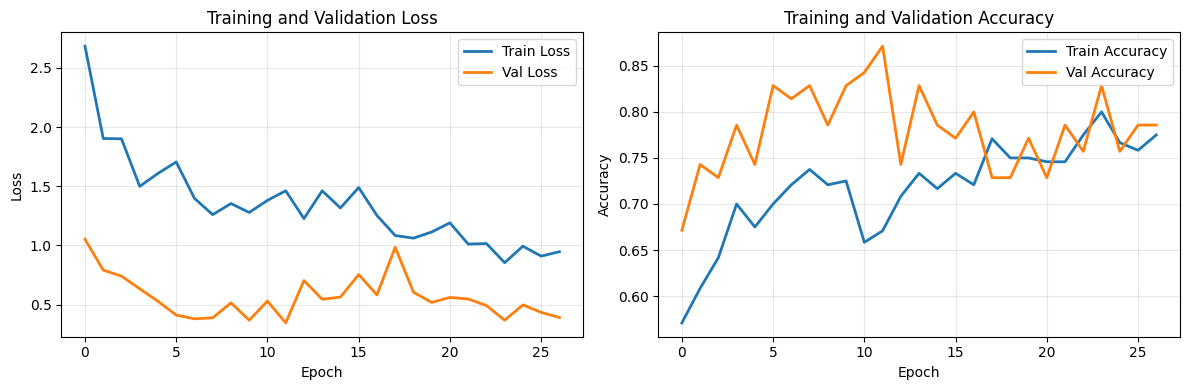

In [18]:
# @title Запуск обучения LSTM

print(f"\n📐 Размерность признаков: {feature_dim}")

# Создание модели
model = CompactLSTMPoseClassifier(
    input_size=feature_dim,
    lstm_hidden=128,
    num_layers=2,
    dropout=0.3
).to(DEVICE)

print(f"\n🧠 Архитектура модели:")
print(f"   Всего параметров: {sum(p.numel() for p in model.parameters()):,}")

# Создание тренера
trainer = LSTMTrainer(model, DEVICE, config)

# Запуск обучения
print("\n" + "="*60)
print("🏋️ ЗАПУСК ОБУЧЕНИЯ")
print("="*60)

trained_model = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    learning_rate=1e-4,
    weight_decay=1e-4,
    patience=15,
    save_path='/content/best_lstm_model.pth'
)

# Визуализация истории обучения
trainer.plot_training_history()

## 📊 Оценка модели на тестовых данных

Проверка качества обученной модели.

✅ Загружена модель с эпохи 12
   Val Loss: 0.3461
   Val Acc: 0.871
📊 РЕЗУЛЬТАТЫ ОЦЕНКИ МОДЕЛИ

Accuracy: 0.8286
AUC-ROC: 0.8933

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.82      0.90      0.86        20
  Defecation       0.85      0.73      0.79        15

    accuracy                           0.83        35
   macro avg       0.83      0.82      0.82        35
weighted avg       0.83      0.83      0.83        35



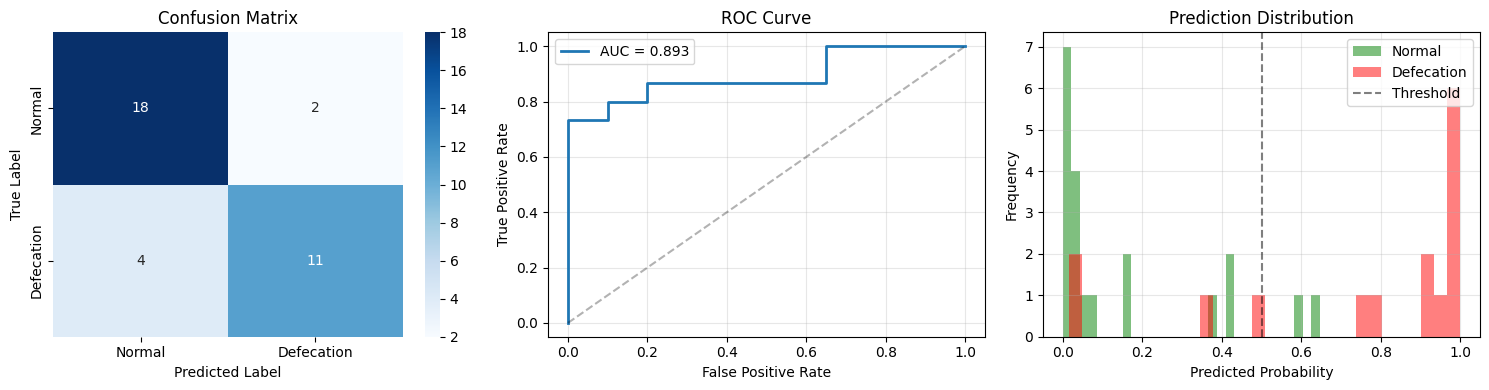

In [19]:
# @title Оценка модели
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, test_loader, device):
    """
    Полная оценка модели
    """
    model.eval()

    all_predictions = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences = sequences.to(device)

            outputs = model(sequences)
            probs = torch.sigmoid(outputs).cpu().numpy()
            predictions = (probs > 0.5).astype(float)

            all_probs.extend(probs)
            all_predictions.extend(predictions)
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs).flatten()
    all_predictions = np.array(all_predictions).flatten()
    all_labels = np.array(all_labels).flatten()

    # Метрики
    accuracy = np.mean(all_predictions == all_labels)
    auc_roc = roc_auc_score(all_labels, all_probs)

    print("="*60)
    print("📊 РЕЗУЛЬТАТЫ ОЦЕНКИ МОДЕЛИ")
    print("="*60)
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")

    print("\n📋 Classification Report:")
    print(classification_report(all_labels, all_predictions,
                               target_names=['Normal', 'Defecation']))

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Defecation'],
                yticklabels=['Normal', 'Defecation'], ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_roc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Distribution of Predictions
    axes[2].hist(all_probs[all_labels==0], bins=30, alpha=0.5, label='Normal', color='green')
    axes[2].hist(all_probs[all_labels==1], bins=30, alpha=0.5, label='Defecation', color='red')
    axes[2].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
    axes[2].set_xlabel('Predicted Probability')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Prediction Distribution')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'accuracy': accuracy,
        'auc_roc': auc_roc,
        'predictions': all_predictions,
        'probabilities': all_probs,
        'labels': all_labels
    }

# Загрузка лучшей модели
best_model = CompactLSTMPoseClassifier(
    input_size=feature_dim,
    lstm_hidden=128,
    num_layers=2,
    dropout=0.3
).to(DEVICE)

checkpoint = torch.load('/content/best_lstm_model.pth', map_location=DEVICE)
best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

print(f"✅ Загружена модель с эпохи {checkpoint['epoch']+1}")
print(f"   Val Loss: {checkpoint['val_loss']:.4f}")
print(f"   Val Acc: {checkpoint['val_acc']:.3f}")

# Оценка на тестовых данных
results = evaluate_model(best_model, test_loader, DEVICE)

## 🔬 Анализ attention весов

Визуализация того, на какие кадры модель обращает внимание при принятии решения.

Анализ примера (истинная метка: Normal)


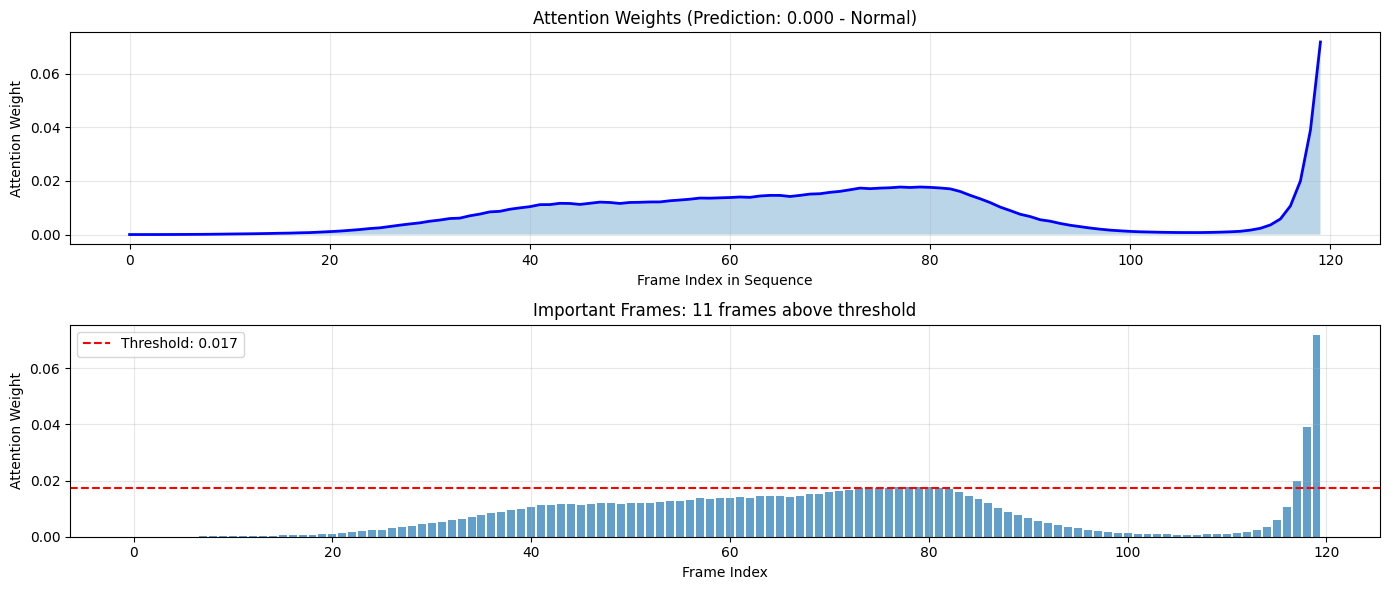

🎯 Наиболее важные кадры: [ 73  75  76  77  78  79  80  81 117 118 119]
   Максимальный вес: 0.072 на кадре 119


In [24]:
# @title Анализ Attention
def visualize_attention(model, sequence, device):
    """
    Визуализация весов внимания для конкретной последовательности
    """
    model.eval()

    sequence_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        # Получаем веса внимания
        attention_weights = model.get_attention_weights(sequence_tensor)
        attention_weights = attention_weights.cpu().numpy().flatten()

        # Получаем предсказание
        output = model(sequence_tensor)
        prob = torch.sigmoid(output).item()

    # Визуализация
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))

    # График весов внимания
    axes[0].plot(attention_weights, linewidth=2, color='blue')
    axes[0].fill_between(range(len(attention_weights)), attention_weights, alpha=0.3)
    axes[0].set_xlabel('Frame Index in Sequence')
    axes[0].set_ylabel('Attention Weight')
    axes[0].set_title(f'Attention Weights (Prediction: {prob:.3f} - {"Defecation" if prob > 0.5 else "Normal"})')
    axes[0].grid(True, alpha=0.3)

    # Выделение важных кадров
    threshold = np.mean(attention_weights) + np.std(attention_weights)
    important_frames = np.where(attention_weights > threshold)[0]

    axes[1].bar(range(len(attention_weights)), attention_weights, alpha=0.7)
    axes[1].axhline(y=threshold, color='red', linestyle='--',
                   label=f'Threshold: {threshold:.3f}')
    axes[1].set_xlabel('Frame Index')
    axes[1].set_ylabel('Attention Weight')
    axes[1].set_title(f'Important Frames: {len(important_frames)} frames above threshold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"🎯 Наиболее важные кадры: {important_frames}")
    print(f"   Максимальный вес: {np.max(attention_weights):.3f} на кадре {np.argmax(attention_weights)}")

    return attention_weights, important_frames

# Пример использования на тестовом примере
sample_sequence, sample_label = next(iter(test_loader))
sample_seq = sample_sequence[0].numpy()

print(f"Анализ примера (истинная метка: {'Defecation' if sample_label[0] > 0.5 else 'Normal'})")
attention_weights, important_frames = visualize_attention(best_model, sample_seq, DEVICE)

## 💾 Экспорт и использование обученной модели

Сохранение модели в формате для production использования.

In [25]:
# @title Экспорт обученной модели
def export_trained_model(model, config, save_path='defecation_lstm_final.pth'):
    """
    Экспорт модели с конфигурацией для использования в production
    """
    # Сохраняем state_dict и конфигурацию
    export_data = {
        'model_state_dict': model.state_dict(),
        'config': {
            'input_size': config.feature_dim * 2,  # base + delta
            'feature_dim': config.feature_dim,
            'lstm_hidden': 128,
            'num_layers': 2,
            'window_size': config.WINDOW_SIZE,
            'threshold': config.DEFECATION_THRESHOLD,
        }
    }

    torch.save(export_data, save_path)
    print(f"✅ Модель экспортирована: {save_path}")

    # Сохраняем отдельно конфигурацию в JSON
    import json
    config_dict = {
        'feature_dim': config.feature_dim,
        'window_size': config.WINDOW_SIZE,
        'threshold': config.DEFECATION_THRESHOLD,
        'input_size': config.feature_dim * 2,
        'model_path': save_path
    }

    json_path = save_path.replace('.pth', '_config.json')
    with open(json_path, 'w') as f:
        json.dump(config_dict, f, indent=2)

    print(f"✅ Конфигурация сохранена: {json_path}")

    return save_path


def load_exported_model(model_path):
    """
    Загрузка экспортированной модели
    """
    checkpoint = torch.load(model_path, map_location='cpu')

    # Создаем модель с сохраненной конфигурацией
    model = CompactLSTMPoseClassifier(
        input_size=checkpoint['config']['input_size'],
        lstm_hidden=checkpoint['config']['lstm_hidden'],
        num_layers=checkpoint['config']['num_layers']
    )

    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"✅ Модель загружена из {model_path}")
    print(f"   Конфигурация: {checkpoint['config']}")

    return model, checkpoint['config']


# Экспорт обученной модели
export_path = export_trained_model(best_model, detector, '/content/defecation_lstm_final.pth')

# Проверка загрузки
loaded_model, loaded_config = load_exported_model(export_path)
print("\n✅ Модель готова к использованию в production")

# Скачивание модели (для Google Colab)
try:
    from google.colab import files
    files.download(export_path)
    files.download(export_path.replace('.pth', '_config.json'))
except:
    pass

AttributeError: 'ImprovedDefecationDetector' object has no attribute 'WINDOW_SIZE'

## 🎯 Использование обученной LSTM в детекторе

Пример интеграции обученной модели в основной детектор.

In [ ]:
# @title Использование обученной LSTM
# Создаем детектор с обученной моделью
production_detector = ImprovedDefecationDetector(
    dog_detect_model=dog_detect_model,
    pose_model=pose_model,
    lstm_path='/content/defecation_lstm_final.pth',  # Путь к обученной модели
    config=config
)

print("✅ Детектор с обученной LSTM готов к работе")

# Пример использования
def process_video_with_trained_model(video_path, output_path):
    """
    Обработка видео с использованием обученной модели
    """
    print(f"🎬 Обработка видео: {video_path}")
    print(f"📊 Используется обученная LSTM модель")

    # Обработка
    production_detector.run_video(video_path, output_path)

    print(f"✅ Результат сохранен: {output_path}")

# Пример использования (раскомментируйте для запуска)
# process_video_with_trained_model(
#     "/path/to/test/video.mp4",
#     "/path/to/output/result.mp4"
# )

print("\n📝 Для использования:")
print("1. Укажите путь к видео в функции process_video_with_trained_model")
print("2. Запустите ячейку")
print("3. Результат будет сохранен с визуализацией детекции")

## 🔄 Дообучение модели (Fine-tuning)

Функция для дообучения модели на новых данных.

In [ ]:
# @title Дообучение модели
def fine_tune_model(model_path, new_data_dir, epochs=20, learning_rate=5e-5):
    """
    Дообучение существующей модели на новых данных
    """
    # Загрузка существующей модели
    print("📥 Загрузка существующей модели...")
    model, model_config = load_exported_model(model_path)
    model = model.to(DEVICE)

    # Подготовка новых данных
    print("🔄 Подготовка новых данных...")

    # Временно создаем детектор для подготовки данных
    temp_detector = ImprovedDefecationDetector(
        dog_detect_model=dog_detect_model,
        pose_model=pose_model,
        lstm_path=model_path,
        config=config
    )

    preparator = DataPreparator(temp_detector, config)
    X_new, y_new = preparator.prepare_dataset(new_data_dir, classes=['normal', 'defecation'])

    print(f"📊 Новые данные: {X_new.shape}")

    # Создание даталоадеров для новых данных
    train_loader, val_loader, _ = create_balanced_dataloaders(
        X_new, y_new,
        batch_size=8,
        val_split=0.2,
        test_split=0.0  # Используем все данные для обучения/валидации
    )

    # Дообучение
    print(f"\n🏋️ Дообучение модели ({epochs} эпох)...")

    trainer = LSTMTrainer(model, DEVICE, config)

    fine_tuned_model = trainer.train(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        weight_decay=1e-5,
        patience=10,
        save_path='/')

## Эксперименты new (3 модели) + углы + метрики

Блок запускает 3 эксперимента для `new`-пайплайна, включая вариант с предопределенными угловыми настройками, и сохраняет все в `models/<experiment_name>/` (`model.pth` + `metrics.md`).

In [26]:
import os
import inspect
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODELS_ROOT = "/content/models"
os.makedirs(MODELS_ROOT, exist_ok=True)

DEVICE_LOCAL = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {DEVICE_LOCAL}")

if "sequences" in globals() and "labels" in globals():
    raw_X = globals()["sequences"]
    raw_y = globals()["labels"]
elif "X" in globals() and "y" in globals():
    raw_X = globals()["X"]
    raw_y = globals()["y"]
else:
    raise ValueError("Не найдены данные. Нужны sequences/labels или X/y.")

X_np = np.asarray(raw_X, dtype=np.float32)
y_np = np.asarray(raw_y)
if y_np.ndim > 1:
    y_np = np.argmax(y_np, axis=1)
y_np = y_np.astype(np.int64)

print("Dataset shape:", X_np.shape, y_np.shape)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_np,
    y_np,
    test_size=0.2,
    random_state=SEED,
    stratify=y_np if len(np.unique(y_np)) > 1 else None
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=SEED,
    stratify=y_temp if len(np.unique(y_temp)) > 1 else None
)

# В new-пайплайне углы часто нормируются в диапазон [-1, 1]
# Для экспериментов определяем "угловые" признаки как близкие к этому диапазону
feature_abs_max = np.nanmax(np.abs(X_train), axis=(0, 1))
angle_feature_mask = feature_abs_max <= 1.1
angle_feature_indices = np.where(angle_feature_mask)[0]
print(f"Detected angle-like features: {len(angle_feature_indices)} / {X_train.shape[2]}")

class SequenceDataset(Dataset):
    def __init__(self, sequences, labels, noise_std=0.0, scale_jitter=0.0,
                 angle_multiplier=1.0, angle_offset=0.0, angle_idx=None):
        self.X = sequences
        self.y = labels
        self.noise_std = noise_std
        self.scale_jitter = scale_jitter
        self.angle_multiplier = angle_multiplier
        self.angle_offset = angle_offset
        self.angle_idx = angle_idx if angle_idx is not None else np.array([], dtype=np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seq = self.X[idx].copy()

        if len(self.angle_idx) > 0:
            seq[:, self.angle_idx] = np.clip(
                seq[:, self.angle_idx] * self.angle_multiplier + self.angle_offset,
                -1.0,
                1.0
            )

        if self.noise_std > 0:
            seq = seq + np.random.normal(0.0, self.noise_std, size=seq.shape).astype(np.float32)

        if self.scale_jitter > 0:
            jitter = np.random.uniform(1.0 - self.scale_jitter, 1.0 + self.scale_jitter)
            seq = seq * np.float32(jitter)

        return torch.tensor(seq, dtype=torch.float32), torch.tensor(int(self.y[idx]), dtype=torch.long)

def create_model(input_size, params, num_classes):
    model_cls = None
    if "CompactLSTMPoseClassifier" in globals():
        model_cls = globals()["CompactLSTMPoseClassifier"]
    elif "LSTMPoseClassifier" in globals():
        model_cls = globals()["LSTMPoseClassifier"]
    else:
        raise ValueError("Не найден класс модели (CompactLSTMPoseClassifier/LSTMPoseClassifier)")

    sig = inspect.signature(model_cls.__init__)
    candidate_kwargs = {
        "input_size": input_size,
        "hidden_size": params.get("hidden_size", 128),
        "lstm_hidden": params.get("hidden_size", 128),
        "num_layers": params.get("num_layers", 2),
        "dropout": params.get("dropout", 0.3),
        "num_classes": num_classes,
        "output_size": num_classes,
        "bidirectional": params.get("bidirectional", True),
        "attention_heads": params.get("attention_heads", 4)
    }

    accepted = {}
    for name, value in candidate_kwargs.items():
        if name in sig.parameters:
            accepted[name] = value

    model = model_cls(**accepted).to(DEVICE_LOCAL)
    return model

def run_experiment(exp_name, params):
    exp_dir = os.path.join(MODELS_ROOT, exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    train_ds = SequenceDataset(
        X_train,
        y_train,
        noise_std=params.get("noise_std", 0.0),
        scale_jitter=params.get("scale_jitter", 0.0),
        angle_multiplier=params.get("angle_multiplier", 1.0),
        angle_offset=params.get("angle_offset", 0.0),
        angle_idx=angle_feature_indices
    )
    val_ds = SequenceDataset(
        X_val,
        y_val,
        angle_multiplier=params.get("angle_multiplier", 1.0),
        angle_offset=params.get("angle_offset", 0.0),
        angle_idx=angle_feature_indices
    )
    test_ds = SequenceDataset(
        X_test,
        y_test,
        angle_multiplier=params.get("angle_multiplier", 1.0),
        angle_offset=params.get("angle_offset", 0.0),
        angle_idx=angle_feature_indices
    )

    train_loader = DataLoader(train_ds, batch_size=params.get("batch_size", 32), shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=params.get("batch_size", 32), shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=params.get("batch_size", 32), shuffle=False)

    num_classes = int(len(np.unique(y_np)))
    model = create_model(input_size=X_np.shape[2], params=params, num_classes=num_classes)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params.get("lr", 1e-3),
        weight_decay=params.get("weight_decay", 1e-4)
    )

    best_val_f1 = -1.0
    best_path = os.path.join(exp_dir, "model.pth")

    epochs = params.get("epochs", 8)
    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE_LOCAL), yb.to(DEVICE_LOCAL)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE_LOCAL)
                logits = model(xb)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds.tolist())
                val_true.extend(yb.numpy().tolist())

        _, _, val_f1, _ = precision_recall_fscore_support(
            val_true,
            val_preds,
            average="weighted",
            zero_division=0
        )

        mean_loss = float(np.mean(train_losses)) if train_losses else 0.0
        print(f"[{exp_name}] Epoch {epoch+1}/{epochs} | loss={mean_loss:.4f} | val_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=DEVICE_LOCAL))
    model.eval()

    all_probs, all_preds, all_true = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE_LOCAL)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_true.extend(yb.numpy().tolist())

    acc = accuracy_score(all_true, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_true,
        all_preds,
        average="weighted",
        zero_division=0
    )

    report_text = classification_report(all_true, all_preds, zero_division=0)
    cm = confusion_matrix(all_true, all_preds)

    sample_examples = []
    for i in range(min(3, len(all_true))):
        sample_examples.append({
            "sample_id": i,
            "true": int(all_true[i]),
            "pred": int(all_preds[i]),
            "probabilities": [round(float(p), 4) for p in all_probs[i]]
        })

    metrics_md = os.path.join(exp_dir, "metrics.md")
    with open(metrics_md, "w", encoding="utf-8") as f:
        f.write(f"# {exp_name}\n\n")
        f.write("## Key metrics\n")
        f.write(f"- accuracy: {acc:.4f}\n")
        f.write(f"- precision (weighted): {precision:.4f}\n")
        f.write(f"- recall (weighted): {recall:.4f}\n")
        f.write(f"- f1 (weighted): {f1:.4f}\n")
        f.write(f"- best_val_f1: {best_val_f1:.4f}\n\n")

        f.write("## Parameters\n")
        for k, v in params.items():
            f.write(f"- {k}: {v}\n")

        f.write("\n## Angle setup\n")
        f.write(f"- angle_like_feature_count: {len(angle_feature_indices)}\n")
        f.write(f"- angle_multiplier: {params.get('angle_multiplier', 1.0)}\n")
        f.write(f"- angle_offset: {params.get('angle_offset', 0.0)}\n\n")

        f.write("## Confusion matrix\n")
        f.write(f"{cm}\n\n")

        f.write("## Classification report\n```\n")
        f.write(report_text)
        f.write("\n```\n\n")

        f.write("## 3 sample predictions\n")
        for ex in sample_examples:
            f.write(
                f"- sample {ex['sample_id']}: true={ex['true']}, pred={ex['pred']}, probs={ex['probabilities']}\n"
            )

    return {
        "experiment": exp_name,
        "model_path": best_path,
        "metrics_path": metrics_md,
        "accuracy": acc,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "samples": sample_examples
    }

experiments = [
    {
        "name": "new_baseline",
        "params": {
            "hidden_size": 128,
            "num_layers": 2,
            "dropout": 0.3,
            "lr": 1e-3,
            "weight_decay": 1e-4,
            "batch_size": 32,
            "epochs": 8,
            "noise_std": 0.0,
            "scale_jitter": 0.0,
            "angle_multiplier": 1.0,
            "angle_offset": 0.0
        }
    },
    {
        "name": "new_angle_preset_focus",
        "params": {
            "hidden_size": 160,
            "num_layers": 2,
            "dropout": 0.35,
            "lr": 8e-4,
            "weight_decay": 3e-4,
            "batch_size": 32,
            "epochs": 10,
            "noise_std": 0.01,
            "scale_jitter": 0.03,
            "angle_multiplier": 1.15,
            "angle_offset": -0.05
        }
    },
    {
        "name": "new_angle_preset_compact",
        "params": {
            "hidden_size": 96,
            "num_layers": 1,
            "dropout": 0.2,
            "lr": 1.5e-3,
            "weight_decay": 1e-5,
            "batch_size": 48,
            "epochs": 6,
            "noise_std": 0.015,
            "scale_jitter": 0.05,
            "angle_multiplier": 0.9,
            "angle_offset": 0.08
        }
    }
]

all_results = []
for exp in experiments:
    print("\n" + "=" * 80)
    print(f"RUN: {exp['name']}")
    result = run_experiment(exp["name"], exp["params"])
    all_results.append(result)

print("\n" + "=" * 80)
print("Готово. Результаты экспериментов:")
for r in all_results:
    print(
        f"- {r['experiment']}: acc={r['accuracy']:.4f}, "
        f"precision={r['precision_weighted']:.4f}, "
        f"recall={r['recall_weighted']:.4f}, "
        f"f1={r['f1_weighted']:.4f}\n"
        f"  model: {r['model_path']}\n"
        f"  metrics: {r['metrics_path']}\n"
        f"  samples: {r['samples']}"
    )

Using device: cuda
Dataset shape: (348, 120, 144) (348,)
Detected angle-like features: 20 / 144

RUN: new_baseline


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## Выгрузка моделей и метрик на компьютер

Архивирует папку `models` и скачивает ZIP на локальный компьютер через интерфейс Google Colab.

In [27]:
import os
import zipfile
from datetime import datetime

try:
    from google.colab import files
except ImportError:
    files = None


def export_models_to_pc(models_dir="/content/models", archive_name=None):
    if not os.path.exists(models_dir):
        raise FileNotFoundError(f"Папка не найдена: {models_dir}")

    if archive_name is None:
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        archive_name = f"models_export_new_{ts}.zip"

    archive_path = os.path.join("/content", archive_name)

    with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, _, filenames in os.walk(models_dir):
            for fn in filenames:
                full_path = os.path.join(root, fn)
                rel_path = os.path.relpath(full_path, start=models_dir)
                zf.write(full_path, arcname=os.path.join("models", rel_path))

    print(f"✅ Архив создан: {archive_path}")

    if files is not None:
        files.download(archive_path)
        print("⬇️ Скачивание запущено (через браузер Colab)")
    else:
        print("ℹ️ Не Colab-среда: файл сохранен локально в /content")

    return archive_path


# Запуск выгрузки
export_models_to_pc()

✅ Архив создан: /content/models_export_new_20260515_150523.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Скачивание запущено (через браузер Colab)


'/content/models_export_new_20260515_150523.zip'